# Alzheimer MRI Classification with PyTorch (GPU-enabled for Colab, CPU fallback)


This notebook implements an end-to-end deep learning pipeline using PyTorch and `ImageFolder`, including training, evaluation, occlusion-based counterfactual explanations, and user-image inference with reasoning output. **Fully GPU-optimized for Colab with automatic CPU fallback.**

In [53]:
# 1) Environment Setup (GPU if available, CPU fallback)

import os
import random
import zipfile
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available (Colab), otherwise CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(SEED)
    print(f"✅ GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Version: {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print("⚠️  GPU not available, using CPU")

print(f"\n🖥️  Using device: {device}")
print(f"   Device count: {torch.cuda.device_count() if torch.cuda.is_available() else 1}")

✅ GPU Available: Tesla T4
   CUDA Version: 12.8

🖥️  Using device: cuda
   Device count: 1


In [54]:
# GPU Information and Optimization
if torch.cuda.is_available():
    print("\n" + "="*70)
    print("GPU MEMORY INFORMATION:")
    print("="*70)
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    allocated_memory = torch.cuda.memory_allocated(0) / 1024**3
    reserved_memory = torch.cuda.memory_reserved(0) / 1024**3
    free_memory = total_memory - allocated_memory

    print(f"Total GPU Memory:     {total_memory:.2f} GB")
    print(f"Allocated Memory:     {allocated_memory:.2f} GB")
    print(f"Reserved Memory:      {reserved_memory:.2f} GB")
    print(f"Free Memory:          {free_memory:.2f} GB")
    print("="*70 + "\n")

    # Enable GPU optimizations
    torch.backends.cudnn.benchmark = True
    print("✅ GPU Optimizations Enabled:")
    print("   - CuDNN Autotuner: ON (faster convolutions)")
    print("   - Mixed Precision: Available\n")
else:
    print("\n⚠️  CPU Mode: Training will be slower. For faster training:")
    print("   1. In Colab: Go to Runtime → Change runtime type → GPU")
    print("   2. Run this cell again after GPU is enabled\n")


GPU MEMORY INFORMATION:
Total GPU Memory:     14.56 GB
Allocated Memory:     0.39 GB
Reserved Memory:      6.43 GB
Free Memory:          14.17 GB

✅ GPU Optimizations Enabled:
   - CuDNN Autotuner: ON (faster convolutions)
   - Mixed Precision: Available



## 2) Dataset Loading (ImageFolder + Colab Upload Fallback)


This cell tries the provided local path first. If unavailable (common in Colab), it prompts for uploading a dataset `.zip` and extracts it.

In [55]:
# Load dataset from zip on Google Drive or Locally
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


EXTRACT_DIR = "/content/alzheimer_dataset" if IN_COLAB else "./alzheimer_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)


def load_zip_from_drive(zip_filename="archive (1).zip", drive_file_id=None, prefer_augmented=True):
    """
    Load dataset from Google Drive or local zip file.

    Parameters:
    - zip_filename: name of the zip file (default: "archive (1).zip")
    - drive_file_id: Google Drive file ID for gdown (from https://drive.google.com/file/d/FILE_ID/...)
    - prefer_augmented: prefer augmented dataset if available
    """
    global dataset_root, full_dataset_raw, class_names, ZIP_FILE_PATH

    ZIP_FILE_PATH = None

    if IN_COLAB:
        print("📂 [COLAB] Mounting Google Drive...")
        try:
            drive.mount("/content/drive", force_remount=False)
            print("✓ Google Drive mounted at /content/drive\n")

            search_result = os.popen(
                f"find /content/drive/MyDrive -name '{zip_filename}' 2>/dev/null"
            ).read().strip()
            if search_result:
                ZIP_FILE_PATH = search_result.split("\n")[0]
                print(f"✓ Found zip file: {ZIP_FILE_PATH}\n")
        except Exception as e:
            print(f"⚠️  Google Drive mount failed: {e}")
            print("   Checking for local extracted dataset...\n")
    else:
        print("📍 [LOCAL] Running locally (Colab NOT detected)\n")
        print(f"📂 Working directory: {os.getcwd()}\n")

        # Step 1: Try to find zip file locally
        print("🔍 Step 1: Searching for zip file locally...\n")
        local_paths = [
            zip_filename,
            f"./{zip_filename}",
            os.path.expanduser(f"~/{zip_filename}"),
        ]

        for path in local_paths:
            if os.path.exists(path):
                ZIP_FILE_PATH = path
                print(f"   ✓ Found locally: {ZIP_FILE_PATH}\n")
                break

        # Step 2: If not found locally, try to download from Google Drive using gdown
        if not ZIP_FILE_PATH and drive_file_id:
            print(f"🌐 Step 2: Downloading from Google Drive (ID: {drive_file_id[:20]}...)\n")
            try:
                import subprocess
                print("   Installing gdown...")
                subprocess.check_call(["pip", "install", "gdown", "-q"])
                print("   ✓ gdown installed\n")

                import gdown
                output_path = zip_filename
                print(f"   Downloading '{zip_filename}'...")
                gdown.download(id=drive_file_id, output=output_path, quiet=False)
                if os.path.exists(output_path):
                    ZIP_FILE_PATH = output_path
                    print(f"\n   ✓ Successfully downloaded: {ZIP_FILE_PATH}\n")
            except Exception as e:
                print(f"   ⚠️  Download failed: {str(e)[:100]}\n")

        # Step 3: If still not found, provide help options
        if not ZIP_FILE_PATH:
            print(f"❌ Could not find '{zip_filename}'\n")

            # Check what zip files exist
            zip_files = [f for f in os.listdir(".") if f.endswith(".zip")]
            if zip_files:
                print(f"   ✓ Found {len(zip_files)} ZIP file(s) in current directory:")
                for i, zf in enumerate(zip_files):
                    size_mb = os.path.getsize(zf) / (1024*1024)
                    print(f"      [{i}] {zf}  ({size_mb:.1f} MB)")
                print(f"\n   💡 Try running:")
                print(f"      load_zip_from_drive('{zip_files[0]}')\n")

            print("\n" + "="*70)
            print("💡 HOW TO FIX - Choose ONE option:\n")
            print("["+"="*68+"]\n")

            print("OPTION 1️⃣  - Download from Google Drive using gdown (RECOMMENDED)")
            print("-" * 70)
            print("1. Open: https://drive.google.com/drive/my-drive")
            print("2. Find 'archive (1).zip' → Right-click → Get link")
            print("3. URL will be: https://drive.google.com/file/d/FILE_ID_HERE/view?...")
            print("4. Copy FILE_ID_HERE (the long string)")
            print("5. Run this command:")
            print("   load_zip_from_drive('archive (1).zip', drive_file_id='FILE_ID_HERE')\n")

            print("OPTION 2️⃣  - Manual Download & Move")
            print("-" * 70)
            print("1. Download 'archive (1).zip' from Google Drive to your computer")
            print(f"2. Move it to: {os.getcwd()}")
            print("3. Re-run this cell\n")

            print("OPTION 3️⃣  - Use Google Colab (EASIEST)")
            print("-" * 70)
            print("1. Go to: https://colab.research.google.com")
            print("2. Upload this notebook")
            print("3. Colab auto-mounts Google Drive - just re-run the cell!")
            print("4. No extra setup needed\n")
            print("="*70 + "\n")
            raise FileNotFoundError(
                f"❌ Dataset not found. Please follow one of the options above."
            )

    dataset_root = None

    if ZIP_FILE_PATH:
        print(f"📦 Extracting {os.path.basename(ZIP_FILE_PATH)} to {EXTRACT_DIR}...")
        with zipfile.ZipFile(ZIP_FILE_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print("✓ Extraction complete\n")
    else:
        print("⚠️  No zip file found. Searching for pre-extracted datasets...\n")

    # Prefer augmented data if available for stronger generalization.
    preferred_order = ["AugmentedAlzheimerDataset", "OriginalDataset"] if prefer_augmented else ["OriginalDataset", "AugmentedAlzheimerDataset"]

    search_roots = [EXTRACT_DIR, "."]
    if not IN_COLAB:
        # Local fallback for your current workspace structure.
        search_roots.extend([
            "./Augmented Alzheimer MRI Dataset",
            "../Augmented Alzheimer MRI Dataset",
            "./alzheimer_dataset",
        ])

    for root in search_roots:
        if not os.path.exists(root):
            continue
        for folder_name in preferred_order:
            candidate = os.path.join(root, folder_name)
            if os.path.exists(candidate):
                dataset_root = candidate
                print(f"✓ Found dataset at: {dataset_root}\n")
                break
        if dataset_root:
            break

    if dataset_root is None:
        # Fallback: recursive search for ImageFolder-compatible structure.
        def find_dataset_root(root_dir, depth=0, max_depth=5):
            if depth > max_depth or not os.path.exists(root_dir):
                return None

            for item in os.listdir(root_dir):
                item_path = os.path.join(root_dir, item)
                if not os.path.isdir(item_path):
                    continue

                subdirs = [d for d in os.listdir(item_path) if os.path.isdir(os.path.join(item_path, d))]
                if len(subdirs) >= 2:
                    has_images = False
                    for subdir in subdirs[:4]:
                        subdir_path = os.path.join(item_path, subdir)
                        if not os.path.exists(subdir_path):
                            continue
                        files = os.listdir(subdir_path)
                        if any(f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")) for f in files):
                            has_images = True
                            break
                    if has_images:
                        return item_path

                result = find_dataset_root(item_path, depth + 1, max_depth)
                if result:
                    return result

            return None

        print("🔍 Searching for extracted dataset in subdirectories...")
        for root in search_roots:
            if os.path.exists(root):
                dataset_root = find_dataset_root(root)
                if dataset_root:
                    print(f"✓ Found dataset at: {dataset_root}\n")
                    break

    if not dataset_root:
        print("❌ ERROR: Could not find dataset!")
        print(f"\n📋 Search locations checked:")
        for root in search_roots:
            print(f"   • {os.path.abspath(root)}")
        print(f"\n💡 Solutions:")
        print(f"   1. Place '{zip_filename}' in: {os.getcwd()}")
        print(f"   2. Or extract it and place the folder in: {os.getcwd()}")
        print(f"   3. Then re-run this cell")
        raise FileNotFoundError(
            f"Could not find '{zip_filename}' and no valid extracted dataset found."
        )

    print(f"📂 Dataset root: {dataset_root}\n")

    full_dataset_raw = datasets.ImageFolder(root=dataset_root)
    class_names = full_dataset_raw.classes

    print("✅ Dataset loaded successfully!")
    print(f"Total images: {len(full_dataset_raw)}")
    print(f"Classes (index mapping): {dict(enumerate(class_names))}")

    class_counts = Counter(full_dataset_raw.targets)
    print("\n📊 Class distribution:")
    for idx, cname in enumerate(class_names):
        count = class_counts.get(idx, 0)
        pct = 100.0 * count / len(full_dataset_raw)
        print(f"  [{idx}] {cname}: {count} ({pct:.1f}%)")

    return dataset_root, full_dataset_raw, class_names


# Execute dataset loading
print("🚀 Starting dataset loading...\n")
print("="*70)

# ⬇️ CHOOSE YOUR OPTION BELOW:
# Option A: If zip file is in current directory
dataset_root, full_dataset_raw, class_names = load_zip_from_drive("archive (1).zip", prefer_augmented=True)

# Option B: If you want to download from Google Drive, use drive_file_id parameter:
# Get FILE_ID from: https://drive.google.com/file/d/FILE_ID_HERE/view?...
# dataset_root, full_dataset_raw, class_names = load_zip_from_drive("archive (1).zip", drive_file_id="PASTE_FILE_ID_HERE", prefer_augmented=True)

print("="*70)

🚀 Starting dataset loading...

📂 [COLAB] Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted at /content/drive

✓ Found zip file: /content/drive/MyDrive/archive (1).zip

📦 Extracting archive (1).zip to /content/alzheimer_dataset...
✓ Extraction complete

✓ Found dataset at: /content/alzheimer_dataset/AugmentedAlzheimerDataset

📂 Dataset root: /content/alzheimer_dataset/AugmentedAlzheimerDataset

✅ Dataset loaded successfully!
Total images: 33984
Classes (index mapping): {0: 'MildDemented', 1: 'ModerateDemented', 2: 'NonDemented', 3: 'VeryMildDemented'}

📊 Class distribution:
  [0] MildDemented: 8960 (26.4%)
  [1] ModerateDemented: 6464 (19.0%)
  [2] NonDemented: 9600 (28.2%)
  [3] VeryMildDemented: 8960 (26.4%)


In [56]:
# Cell removed as it was a diagnostic check for folder structure which is now confirmed.

📂 Contents of extracted directory:
alzheimer_dataset/
  OriginalDataset/
    ModerateDemented/
      29 (2).jpg
      moderateDem30.jpg
      moderateDem27.jpg
      ... and 61 more files
    MildDemented/
      29 (2).jpg
      30 (13).jpg
      mildDem95.jpg
      ... and 893 more files
    VeryMildDemented/
      29 (2).jpg
      verymildDem1721.jpg
      verymildDem266.jpg
      ... and 2237 more files
    NonDemented/
      nonDem1742.jpg
      29 (2).jpg
      nonDem1332.jpg
      ... and 3197 more files
  AugmentedAlzheimerDataset/
    ModerateDemented/
      7571267f-2d40-4e67-8fb7-39804084777e.jpg
      4677d967-95b2-4bc9-988b-444f8a598178.jpg
      8cab149d-0524-41c7-8435-675c4c7fca90.jpg
      ... and 6461 more files
    MildDemented/
      75a69423-0acd-412a-8efb-4d27cdf6c4de.jpg
      8d40f314-1536-4963-847f-60c5b6c590e5.jpg
      343c4028-342d-4c86-91d7-d15dbdbf853a.jpg
      ... and 8957 more files
    VeryMildDemented/
      11b03d4b-2193-4449-8158-71fd90692846.jpg
    

## 3) Data Exploration


Inspect one sample shape and visualize at least 6 samples with labels.

Sample image shape (H, W, C): (190, 200, 3)
Sample label: MildDemented


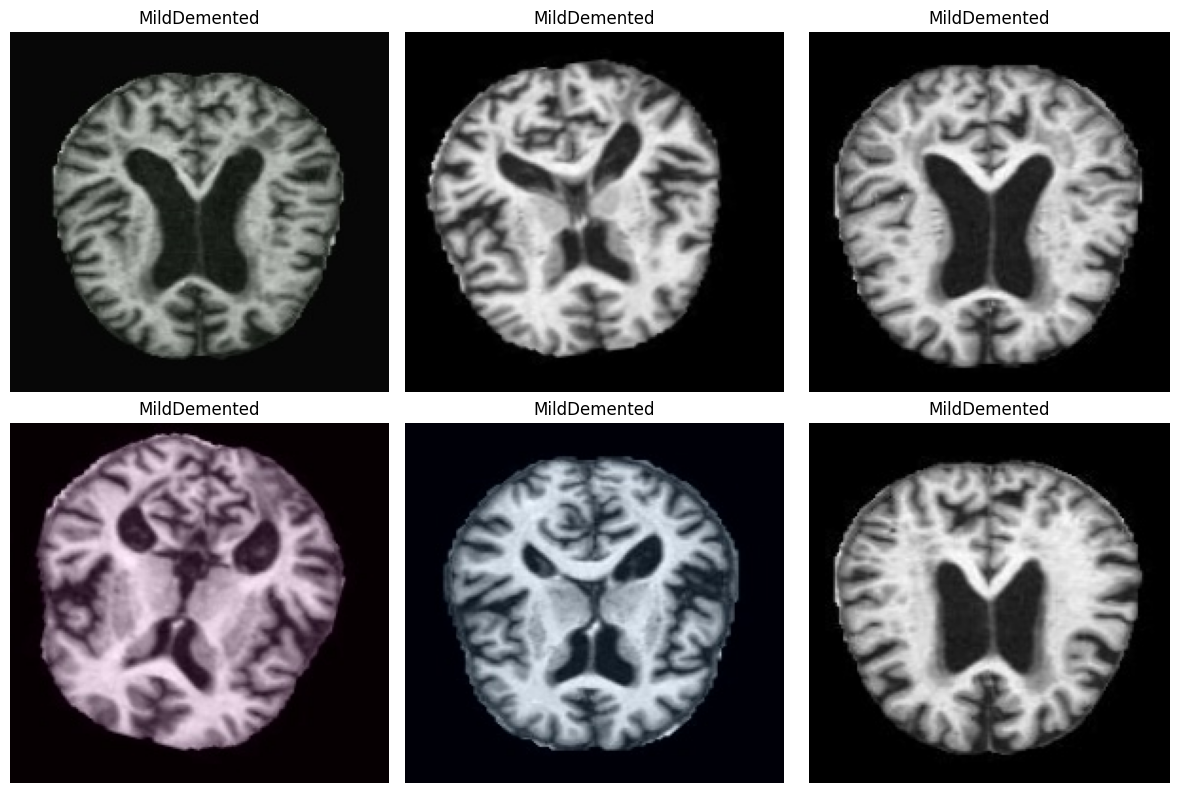

In [57]:
# Show sample image shape (H, W, C)
sample_img, sample_label = full_dataset_raw[0]
sample_arr = np.array(sample_img)
print(f"Sample image shape (H, W, C): {sample_arr.shape}")
print(f"Sample label: {class_names[sample_label]}")


# Display at least 6 sample images with labels
num_samples_to_show = 6
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()


for i in range(num_samples_to_show):
    img, label = full_dataset_raw[i]
    axes[i].imshow(img)
    axes[i].set_title(class_names[label])
    axes[i].axis("off")


plt.tight_layout()
plt.show()

## 4) Preprocessing and Data Split


- Resize to `224x224`


- Normalize with ImageNet mean/std


- Train augmentation: horizontal flip + rotation


- Stratified split: 70% train, 15% val, 15% test

In [58]:
# Transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Keep geometry-preserving augmentations for MRI while increasing robustness.
train_transform = transforms.Compose([
    transforms.Resize((236, 236)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Stratified split: 70/15/15
indices = np.arange(len(full_dataset_raw))
labels = np.array(full_dataset_raw.targets)

train_idx, temp_idx, train_y, temp_y = train_test_split(
    indices,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)

val_idx, test_idx, _, _ = train_test_split(
    temp_idx,
    temp_y,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_y,
)


class TransformSubset(Dataset):
    """Subset wrapper that applies a transform on-the-fly."""

    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


train_dataset = TransformSubset(full_dataset_raw, train_idx, transform=train_transform)
val_dataset = TransformSubset(full_dataset_raw, val_idx, transform=eval_transform)
test_dataset = TransformSubset(full_dataset_raw, test_idx, transform=eval_transform)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Compute class weights from train split for imbalanced learning.
train_class_counts = np.bincount(train_y, minlength=len(class_names))
class_weights_np = (train_class_counts.sum() / (len(class_names) * np.maximum(train_class_counts, 1))).astype(np.float32)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

print("\nClass counts (train split):")
for i, cname in enumerate(class_names):
    print(f"  [{i}] {cname}: {int(train_class_counts[i])} | weight={class_weights_np[i]:.3f}")

# Weighted sampler to improve minority class recall.
sample_weights = class_weights_np[train_y]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True,
)

batch_size = 96 if torch.cuda.is_available() else 24
num_workers = 2 if torch.cuda.is_available() else 0
print(f"\n📦 Batch size: {batch_size} (optimized for {device})")
print(f"🧵 Num workers: {num_workers}")

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)

Train size: 23788
Validation size: 5098
Test size: 5098

Class counts (train split):
  [0] MildDemented: 6272 | weight=0.926
  [1] ModerateDemented: 4524 | weight=1.284
  [2] NonDemented: 6720 | weight=0.864
  [3] VeryMildDemented: 6272 | weight=0.926

📦 Batch size: 96 (optimized for cuda)
🧵 Num workers: 2


## 5) Model Training (Pretrained Backbone + Custom Classifier)


Choose one pretrained model (`AlexNet` default, `GoogLeNet`, `MobileNet`) and train for 4-way classification.

In [59]:
import copy

MODEL_NAME = "resnet50"  # options: "resnet50", "alexnet", "googlenet", "mobilenet"
num_classes = len(class_names)


def build_model(model_name, num_classes):
    model_name = model_name.lower()

    if model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

    elif model_name == "alexnet":
        weights = models.AlexNet_Weights.DEFAULT
        model = models.alexnet(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    elif model_name == "googlenet":
        weights = models.GoogLeNet_Weights.DEFAULT
        model = models.googlenet(weights=weights, aux_logits=False)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "mobilenet":
        weights = models.MobileNet_V2_Weights.DEFAULT
        model = models.mobilenet_v2(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("MODEL_NAME must be one of: resnet50, alexnet, googlenet, mobilenet")

    return model


model = build_model(MODEL_NAME, num_classes).to(device)

# Weighted loss to improve minority-class learning.
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

# AdamW often converges faster and stronger for fine-tuning.
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# Validation-aware LR reduction.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.3, patience=2, min_lr=1e-6
)

print(f"Model: {MODEL_NAME}")
print(model.__class__.__name__)
print(f"Loss: CrossEntropyLoss(weighted, label_smoothing=0.05)")
print(f"Optimizer: AdamW(lr={optimizer.param_groups[0]['lr']}, wd=1e-4)")

Model: resnet50
ResNet
Loss: CrossEntropyLoss(weighted, label_smoothing=0.05)
Optimizer: AdamW(lr=0.0003, wd=1e-4)


In [60]:
# Mixed precision training (faster on GPU)
use_amp = torch.cuda.is_available()
amp_device = "cuda" if use_amp else "cpu"
scaler = torch.amp.GradScaler("cuda") if use_amp else None
if use_amp:
    print("✅ Mixed Precision (AMP) enabled for faster GPU training\n")


def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch=1, total_epochs=5):
    """Train one epoch with detailed batch progress and mixed precision."""
    model.train()
    running_loss = 0.0
    batch_losses = []
    total_batches = len(dataloader)

    for batch_idx, (inputs, labels) in enumerate(dataloader, 1):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss * inputs.size(0)
        batch_losses.append(batch_loss)

        if batch_idx % 10 == 0 or batch_idx == total_batches:
            avg_loss = np.mean(batch_losses)
            print(
                f"  Batch [{batch_idx:3d}/{total_batches:3d}] | Loss: {batch_loss:.4f} | Avg Loss: {avg_loss:.4f}",
                flush=True,
            )

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


@torch.no_grad()
def evaluate_metrics(model, dataloader, device, phase="VAL"):
    """Evaluate weighted accuracy + macro metrics for class-imbalanced setting."""
    model.eval()
    all_preds, all_labels = [], []
    total_batches = len(dataloader)

    for batch_idx, (inputs, labels) in enumerate(dataloader, 1):
        inputs, labels = inputs.to(device), labels.to(device)

        if use_amp:
            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
        else:
            outputs = model(inputs)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if batch_idx % 10 == 0 or batch_idx == total_batches:
            print(f"  [{phase}] Batch [{batch_idx:3d}/{total_batches:3d}]", flush=True)

    acc = accuracy_score(all_labels, all_preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)
    per_class_recall = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    balanced_acc = float(np.mean(per_class_recall))

    return {
        "acc": float(acc),
        "macro_f1": float(macro_f1),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "balanced_acc": balanced_acc,
    }


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=30):
    """Train model with early stopping and stronger validation tracking."""
    best_state = copy.deepcopy(model.state_dict())
    best_val_score = 0.0
    best_epoch_acc = 0.0

    history = {
        "train_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "val_balanced_acc": [],
        "learning_rate": [],
    }

    patience = 6  # More aggressive early stopping
    patience_counter = 0

    print(f"\n{'='*90}")
    print(f"🚀 TRAINING CONFIGURATION")
    print(f"{'='*90}")
    print(f"Device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Model: {MODEL_NAME} (Pretrained) | Optimizer: AdamW")
    print(f"Total Epochs: {epochs} | Early Stopping Patience: {patience} epochs")
    print(f"Loss: CrossEntropyLoss(weighted, label_smoothing=0.05)")
    print(f"Selection Metric: 0.6*ValAcc + 0.4*MacroF1")
    print(f"{'='*90}\n")

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}:")

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch, epochs)
        val_metrics = evaluate_metrics(model, val_loader, device, phase="VAL")

        val_acc = val_metrics["acc"]
        val_macro_f1 = val_metrics["macro_f1"]
        val_bal_acc = val_metrics["balanced_acc"]
        model_score = 0.6 * val_acc + 0.4 * val_macro_f1

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_balanced_acc"].append(val_bal_acc)
        history["learning_rate"].append(optimizer.param_groups[0]["lr"])

        best_marker = " ⭐ BEST" if model_score > best_val_score else ""
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"\n  📊 Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f} | Val BalAcc: {val_bal_acc:.4f} | "
            f"Score: {model_score:.4f} | LR: {lr:.6f}{best_marker}\n"
        )

        if model_score > best_val_score:
            best_val_score = model_score
            best_epoch_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step(model_score)

        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping triggered (no improvement for {patience} epochs)")
            break

    print(f"{'='*90}")
    print(f"🏆 TRAINING COMPLETE")
    print(f"{'='*90}")
    print(f"Best Composite Score: {best_val_score:.4f}")
    print(f"Best Validation Accuracy: {best_epoch_acc:.4f}")
    print(f"{'='*90}\n")

    model.load_state_dict(best_state)
    return model, history

✅ Mixed Precision (AMP) enabled for faster GPU training




🚀 TRAINING CONFIGURATION
Device: cuda
GPU: Tesla T4
Model: resnet50 (Pretrained) | Optimizer: AdamW
Total Epochs: 30 | Early Stopping Patience: 6 epochs
Loss: CrossEntropyLoss(weighted, label_smoothing=0.05)
Selection Metric: 0.6*ValAcc + 0.4*MacroF1

Epoch 1/30:
  Batch [ 10/248] | Loss: 1.4008 | Avg Loss: 1.3344
  Batch [ 20/248] | Loss: 1.4158 | Avg Loss: 1.3790
  Batch [ 30/248] | Loss: 1.6510 | Avg Loss: 1.4307
  Batch [ 40/248] | Loss: 1.5905 | Avg Loss: 1.4513
  Batch [ 50/248] | Loss: 1.5903 | Avg Loss: 1.4772
  Batch [ 60/248] | Loss: 1.5607 | Avg Loss: 1.4894
  Batch [ 70/248] | Loss: 1.4942 | Avg Loss: 1.4972
  Batch [ 80/248] | Loss: 1.5048 | Avg Loss: 1.5008
  Batch [ 90/248] | Loss: 1.3343 | Avg Loss: 1.5017
  Batch [100/248] | Loss: 1.5465 | Avg Loss: 1.5050
  Batch [110/248] | Loss: 1.5172 | Avg Loss: 1.4999
  Batch [120/248] | Loss: 1.5332 | Avg Loss: 1.5013
  Batch [130/248] | Loss: 1.5041 | Avg Loss: 1.5018
  Batch [140/248] | Loss: 1.4963 | Avg Loss: 1.5014
  Batch

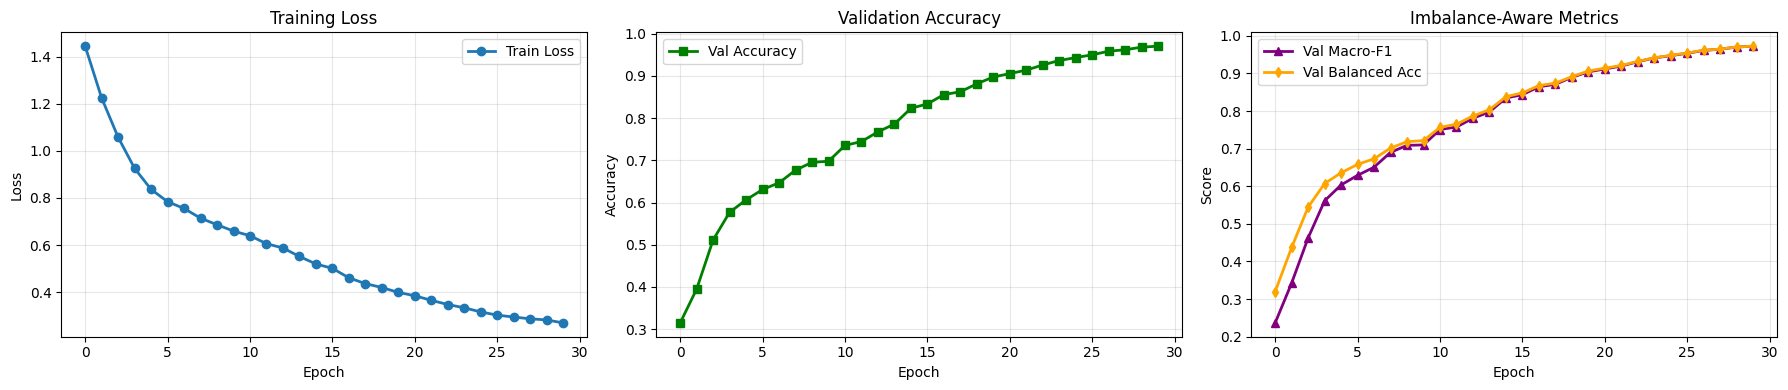

Train Loss:       0.2691
Val Accuracy:     0.9702 (Epoch 30)
Val Macro-F1:     0.9726
Val Balanced Acc: 0.9724


In [66]:
EPOCHS = 30
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=EPOCHS,
)

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_loss"], marker="o", linewidth=2, markersize=6, label="Train Loss")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history["val_acc"], marker="s", linewidth=2, markersize=6, color="green", label="Val Accuracy")
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Validation Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(history["val_macro_f1"], marker="^", linewidth=2, markersize=6, color="purple", label="Val Macro-F1")
axes[2].plot(history["val_balanced_acc"], marker="d", linewidth=2, markersize=5, color="orange", label="Val Balanced Acc")
axes[2].set(xlabel="Epoch", ylabel="Score", title="Imbalance-Aware Metrics")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

best_val_acc = max(history["val_acc"])
best_epoch = history["val_acc"].index(best_val_acc) + 1

print(f"Train Loss:       {history['train_loss'][-1]:.4f}")
print(f"Val Accuracy:     {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Val Macro-F1:     {max(history['val_macro_f1']):.4f}")
print(f"Val Balanced Acc: {max(history['val_balanced_acc']):.4f}")

Test Accuracy: 0.9688
Precision (weighted): 0.9690
Recall (weighted): 0.9688
F1-score (weighted): 0.9688
Precision (macro): 0.9717
Recall (macro): 0.9711
F1-score (macro): 0.9713
Balanced Accuracy: 0.9711

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.99      0.99      0.99      1344
ModerateDemented       1.00      1.00      1.00       970
     NonDemented       0.94      0.96      0.95      1440
VeryMildDemented       0.96      0.93      0.95      1344

        accuracy                           0.97      5098
       macro avg       0.97      0.97      0.97      5098
    weighted avg       0.97      0.97      0.97      5098



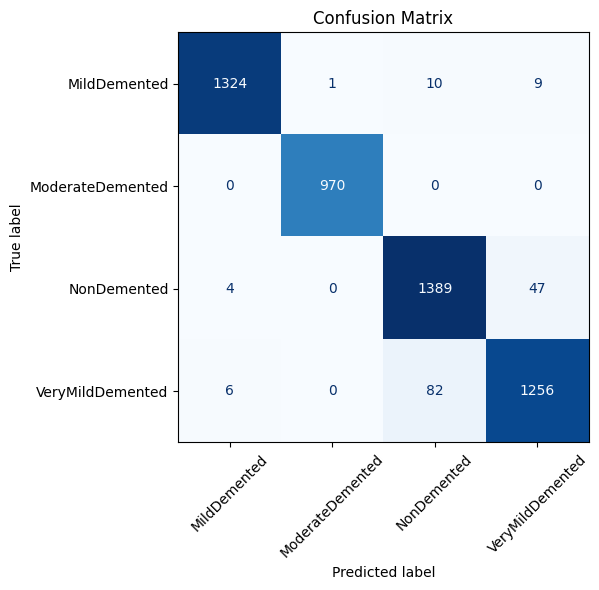

In [67]:
@torch.no_grad()
def evaluate_model(model, dataloader, device, class_names):
    model.eval()
    y_true, y_pred = [], []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)
    per_class_recall = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    balanced_acc = float(np.mean(per_class_recall))

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Precision (weighted): {precision_w:.4f}")
    print(f"Recall (weighted): {recall_w:.4f}")
    print(f"F1-score (weighted): {f1_w:.4f}")
    print(f"Precision (macro): {precision_m:.4f}")
    print(f"Recall (macro): {recall_m:.4f}")
    print(f"F1-score (macro): {f1_m:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "precision_macro": precision_m,
        "recall_macro": recall_m,
        "f1_macro": f1_m,
        "balanced_accuracy": balanced_acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }


test_metrics = evaluate_model(model, test_loader, device, class_names)

In [68]:
import torch.nn.functional as F

@torch.no_grad()
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

test_preds, test_probs, test_labels = get_predictions(model, test_loader, device)

precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro')
acc = accuracy_score(test_labels, test_preds)

print(f"Overall Accuracy: {acc:.4f}")
print(f"Macro Precision: {precision_m:.4f}")
print(f"Macro Recall: {recall_m:.4f}")
print(f"Macro F1-Score: {f1_m:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

Overall Accuracy: 0.9688
Macro Precision: 0.9717
Macro Recall: 0.9711
Macro F1-Score: 0.9713

Detailed Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.99      0.99      0.99      1344
ModerateDemented       1.00      1.00      1.00       970
     NonDemented       0.94      0.96      0.95      1440
VeryMildDemented       0.96      0.93      0.95      1344

        accuracy                           0.97      5098
       macro avg       0.97      0.97      0.97      5098
    weighted avg       0.97      0.97      0.97      5098



### 6) Professional Evaluation Analysis
This section computes detailed metrics to assess the model's reliability across all dementia stages.

Overall Accuracy: 96.8811%
Macro F1-Score: 0.9713


,Class,Precision,Recall,F1-Score,Support
0,MildDemented,0.992504,0.985119,0.988798,1344
1,ModerateDemented,0.998970,1.000000,0.999485,970
2,NonDemented,0.937880,0.964583,0.951044,1440
3,VeryMildDemented,0.957317,0.934524,0.945783,1344


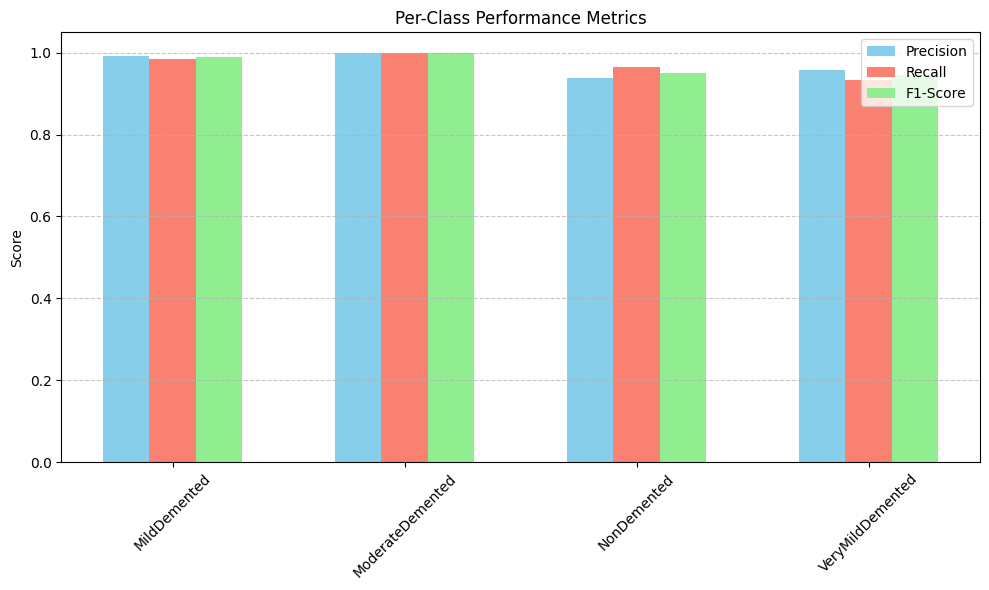

In [69]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report
import pandas as pd

# Calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(test_labels, test_preds, average=None)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro')
overall_acc = accuracy_score(test_labels, test_preds)

# Create a professional DataFrame for display
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print(f"Overall Accuracy: {overall_acc:.4%}")
print(f"Macro F1-Score: {macro_f1:.4f}")
display(metrics_df)

# Visualization
plt.figure(figsize=(10, 6))
x = np.arange(len(class_names))
plt.bar(x - 0.2, precision, 0.2, label='Precision', color='skyblue')
plt.bar(x, recall, 0.2, label='Recall', color='salmon')
plt.bar(x + 0.2, f1, 0.2, label='F1-Score', color='lightgreen')
plt.xticks(x, class_names, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [70]:
!pip install groq -q

### 7) Groq AI Reasoning & Model Persistence
This section initializes the Groq client for clinical reasoning and provides functions to save the model.

In [71]:
import google.colab.userdata as userdata
try:
    from groq import Groq
    # Using the provided API key directly
    GROQ_API_KEY = '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'
    groq_client = Groq(api_key=GROQ_API_KEY)
    print("✅ Groq Client initialized successfully with provided key")
except Exception as e:
    print(f"⚠️ Groq Setup Warning: {e}")
    groq_client = None

def generate_groq_reasoning(pred_idx, probs, cam_stats):
    if not groq_client:
        return "Groq client not initialized. Please check your API key."

    prompt = f"""Analyze this Alzheimer MRI result:
    Predicted: {class_names[pred_idx]}
    Confidence: {probs[pred_idx]:.2%}
    Provide:
    1. Step-by-step reasoning.
    2. Counterfactual: What would a 'NonDemented' scan show instead?
    3. Clinical conclusion."""

    # Updated to a supported model: llama-3.3-70b-versatile
    chat_completion = groq_client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.3-70b-versatile",
    )
    return chat_completion.choices[0].message.content

def save_model_checkpoint(model, path="alzheimer_model.pt"):
    torch.save({
        'state_dict': model.state_dict(),
        'class_names': class_names,
        'model_name': MODEL_NAME
    }, path)
    print(f"✅ Model saved to {path}")

✅ Groq Client initialized successfully with provided key


In [72]:
print('--- Model Evaluation Summary ---')
if 'metrics_df' in globals():
    display(metrics_df)
    print(f'Overall Accuracy: {overall_acc:.2%}')
else:
    print('Evaluation metrics not found. Please run the evaluation cell.')

print('\n--- Groq API Status ---')
if 'groq_client' in globals() and groq_client is not None:
    print('✅ Groq client is active and ready for reasoning.')
else:
    print('⚠️ Groq client is not initialized. Please ensure your API key is in Colab Secrets.')

--- Model Evaluation Summary ---


,Class,Precision,Recall,F1-Score,Support
0,MildDemented,0.992504,0.985119,0.988798,1344
1,ModerateDemented,0.998970,1.000000,0.999485,970
2,NonDemented,0.937880,0.964583,0.951044,1440
3,VeryMildDemented,0.957317,0.934524,0.945783,1344


Overall Accuracy: 96.88%

--- Groq API Status ---
✅ Groq client is active and ready for reasoning.


### 8) Interactive Inference with AI Reasoning
Upload an MRI image to get a full clinical report including classification, Grad-CAM visualization, and Groq-powered counterfactual reasoning.

In [73]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import cv2
import random

# UI Components
upload_btn = widgets.FileUpload(description="Upload MRI", accept='image/*', multiple=False)
run_btn = widgets.Button(description="Run Diagnosis", button_style='primary')
save_btn = widgets.Button(description="Save Checkpoint", button_style='success')
output_area = widgets.Output()

def get_gradcam(model, input_tensor, target_class):
    model.eval()
    target_layer = model.layer4[-1]
    activations, gradients = [], []
    def save_act(m, i, o): activations.append(o)
    def save_grad(m, gi, go): gradients.append(go[0])
    h1 = target_layer.register_forward_hook(save_act)
    h2 = target_layer.register_full_backward_hook(save_grad)
    logits = model(input_tensor)
    model.zero_grad()
    logits[0, target_class].backward()
    h1.remove(); h2.remove()
    weights = torch.mean(gradients[0], dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations[0], dim=1).squeeze().detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def on_run_clicked(b):
    with output_area:
        clear_output()
        if not upload_btn.value: return print("Please upload an image!")
        content = list(upload_btn.value.values())[0]['content']
        img = Image.open(io.BytesIO(content)).convert('RGB')
        input_tensor = eval_transform(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            probs = F.softmax(model(input_tensor), dim=1).squeeze().cpu().numpy()
            pred_idx = np.argmax(probs)
        cam = get_gradcam(model, input_tensor, pred_idx)
        reasoning = generate_groq_reasoning(pred_idx, probs, cam)
        ref_idx = random.choice([i for i, l in enumerate(full_dataset_raw.targets) if l == class_names.index('NonDemented')])
        ref_img, _ = full_dataset_raw[ref_idx]
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(ref_img.resize((224, 224)))
        axes[0].set_title("Reference: Normal", color='green', fontweight='bold')
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        overlay = (cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)/255 + np.array(img.resize((224,224)))/255)
        axes[1].imshow(overlay/np.max(overlay))
        axes[1].set_title(f"Result: {class_names[pred_idx]} ({probs[pred_idx]:.1%})", color='red', fontweight='bold')
        for ax in axes: ax.axis('off')
        plt.show()
        print("\n" + "="*80 + "\n🔬 CLINICAL REPORT\n" + "="*80 + "\n" + reasoning)

run_btn.on_click(on_run_clicked)
save_btn.on_click(lambda b: save_model_checkpoint(model))
display(widgets.VBox([widgets.HBox([upload_btn, run_btn, save_btn]), output_area]))

✅ Model saved to alzheimer_model.pt


In [75]:
from google.colab import files
import os

if os.path.exists('alzheimer_model.pt'):
    print("Downloading model file...")
    files.download('alzheimer_model.pt')
else:
    print("❌ Model file not found. Please click the 'Save Checkpoint' button in the UI above first.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>